# Import and inputs

In [8]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = str(Path("..").resolve())
case_study_root = str(Path(".").resolve())
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
import re

from SynFlow.Explorer import (
    compute_saturating_support_from_sfiller_df,
    rel_explorer,
    spath_comb_explorer,
    spath_to_constructiondf,
    trim_and_merge,
)
from SynFlow.Explorer.trimming import spe_group
from SynFlow.SCD import (
    compute_consecutive_dist_df,
    compute_weighted_consecutive_dist_df,
    compute_period_period_dist,
    multiply_consecutive_dist_saturating_support,
    permutation_test_consecutive_dist,
    plot_all_dists_by_period,
    plot_permutation_test_consecutive_dist,
    plot_period_period_dist,
    summarize_fdr_correction,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Specify required input
# Regex corpus_pattern to extract relevant information from SynFlow parsed files
corpus_pattern = re.compile(
    r"([^\t]+)\t"      # word form
    r"([^\t]+)\t"      # lemma
    r"([^\t]+)\t"      # POS (UPOS or XPOS)
    r"([^\t]+)\t"      # ID
    r"([^\t]+)\t"      # HEAD
    r"([^\t]+)\t"      # DEPREL
    r"([^\t]+)"        # FEATS
)

# Specify target lemma and part of speech
target_lemma = "viral"
target_pos = "ADJ"

# Specify corpus and output folders
period = "1995-2025"
corpus_folder = f"/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed"
output_folder = Path(".").resolve()

In [10]:
# Dont change below this line
output_folder_lemma = output_folder / "output" / f"{target_lemma}_{target_pos}_{period}"
output_explorer = f"{output_folder_lemma}/Explorer"
output_embedding = f"{output_folder_lemma}/Embedding"
input_SCD = output_folder / "input" /f"{target_lemma}_{target_pos}_{period}" / "SCD"
output_SCD = output_folder / "output" / f"{target_lemma}_{target_pos}_{period}" / "SCD"

os.makedirs(output_explorer, exist_ok=True)
os.makedirs(output_embedding, exist_ok=True)
os.makedirs(input_SCD, exist_ok=True)
os.makedirs(output_SCD, exist_ok=True)

# Explore the distribution of different slot combinations

## Unique slot combination frequencies

[1995-2000] Total instances: 47, distinct patterns: 5


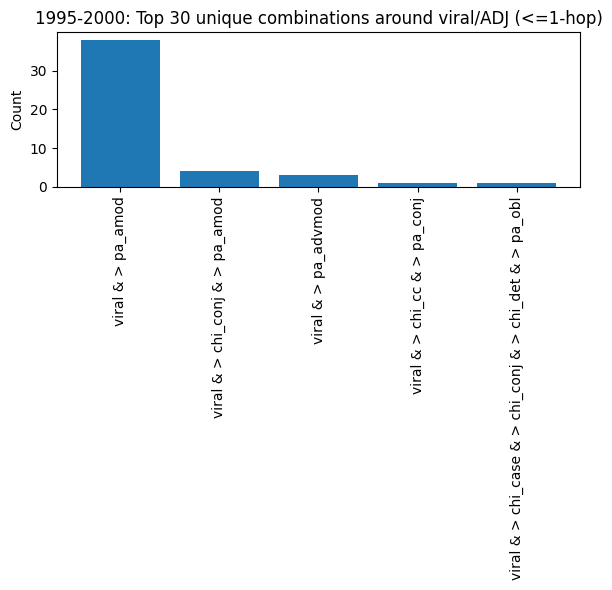

[2001-2005] Total instances: 30, distinct patterns: 4


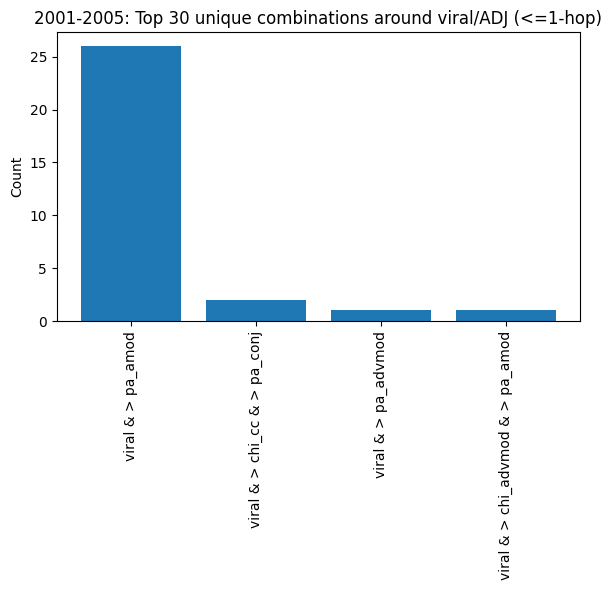

[2006-2010] Total instances: 110, distinct patterns: 6


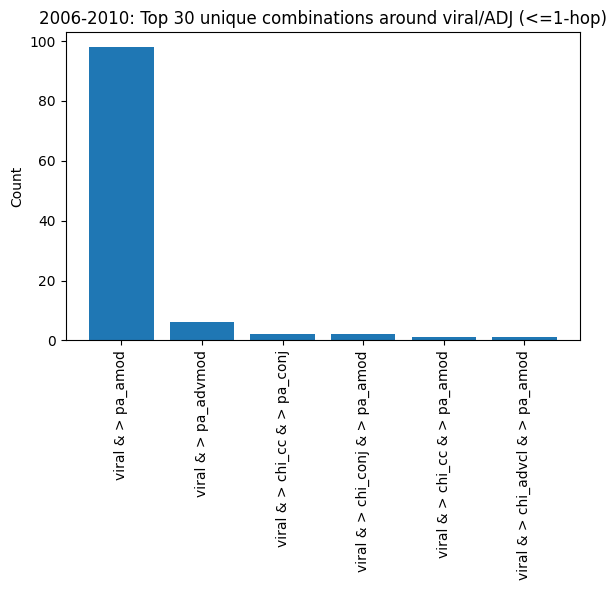

[2011-2015] Total instances: 169, distinct patterns: 14


/home/volt/bach/SynFlow/SynFlow/Explorer/spath_explorer.py:79: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


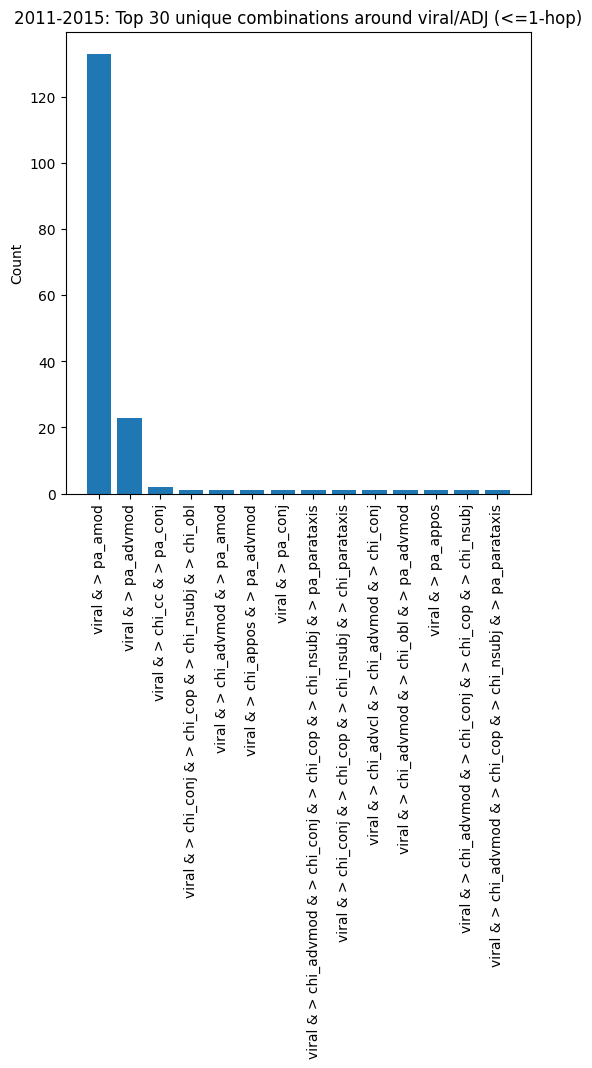

[2016-2020] Total instances: 270, distinct patterns: 11


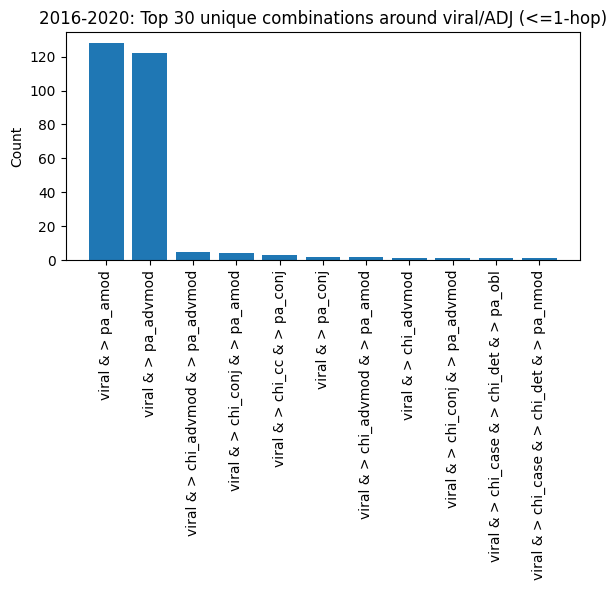

[2021-2025] Total instances: 566, distinct patterns: 20


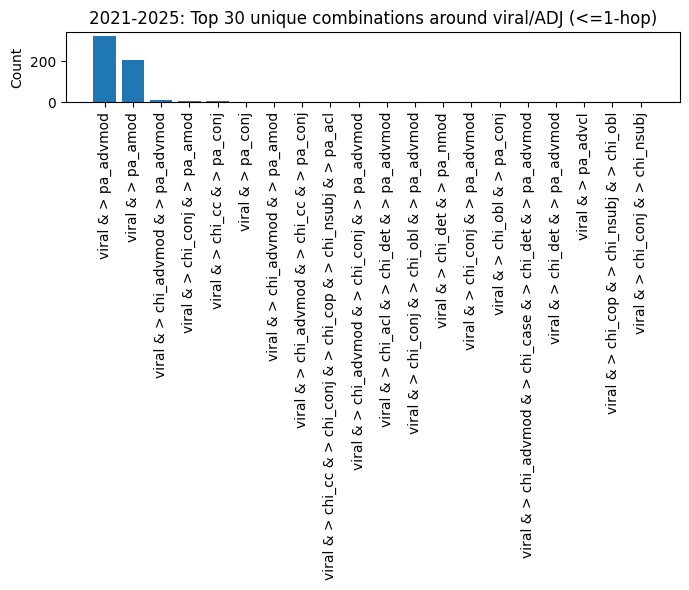

CSV saved to /home/volt/bach/SynFlow/notebooks/output/viral_ADJ_1995-2025/Explorer/viral_ADJ_spath_combs_1_hops.csv


In [11]:
# 1 unique full-pattern string for 1 token

trimmed_rels = ["chi_punct"]

ctr = spath_comb_explorer(
    corpus_folder=corpus_folder,
    target_lemma=target_lemma,
    target_pos=target_pos,
    max_length=1,
    top_n=30,
    output_folder=output_explorer,
    pattern=corpus_pattern,
    trimmed_rels=trimmed_rels,
)

## Rel explorer
* You can explore what the slots mean here, either single slot or the whole combination

### Single slot

In [12]:
rel_single_path_results = rel_explorer(
    corpus_folder=corpus_folder,
    pattern=corpus_pattern,
    target_lemma=target_lemma,
    target_pos=target_pos,
    deprel="> (pa_amod, [])",
    filler_format="lemma/deprel", # lemma_only, lemma/pos, lemma/deprel, token_only, token/pos, token/deprel
    # Single-path searches always use open matching.
)

rel_single_path_results


,sentence_id,sentence,sfillers,path
0,1995_164115,Die gentechnisch umprogrammierten viralen Gen ...,[Gen/pa_amod],pa_amod
1,1995_256783,Diese Zytokine werden außerhalb des Gehirns au...,[unknown/pa_amod],pa_amod
2,1995_368117,Virale und viroide Systeme sind nicht eingesch...,[System/pa_amod],pa_amod
3,1995_455269,"S Andree , Christoph Freiburg Untersuchungen z...",[Gentransfer/pa_amod],pa_amod
4,1995_489161,Allerdings messen viele Experten dem Einfluß v...,[Infektion/pa_amod],pa_amod
...,...,...,...,...
646,2025_900107,Virales Video zeigt mutmaßlichen Wolf in NRW -...,[Video/pa_amod],pa_amod
647,2025_919143,"Was als viraler TikTok - Trend begann , entwic...",[TikTok/pa_amod],pa_amod
648,2025_922356,"Washington , D.C./Chicago – Ein virales Foto a...",[Foto/pa_amod],pa_amod
649,2025_934978,Wenn Chefs sich als Opfer ihrer Mitarbeiter da...,[unknown/pa_amod],pa_amod


In [13]:
out_path = f"{output_explorer}/rel_1_path_explorer.tsv"
rel_single_path_results.to_csv(out_path, sep="\t", index=False)


### Slot combination


In [14]:
rel_multi_path_results = rel_explorer(
    corpus_folder=corpus_folder,
    pattern=corpus_pattern,
    target_lemma=target_lemma,
    target_pos=target_pos,
    deprel="> (chi_conj, []) & > (pa_advmod, [])",
    search_mode="open", # open, close, closeh; only applied when there are multiple paths
    filler_format="lemma/pos", # lemma_only, lemma/pos, lemma/deprel, token_only, token/pos, token/deprel
)

rel_multi_path_results


,sentence_id,sentence,sfillers,path
0,2017_740173,Nun gehen diese Bilder viral und Sorgen für vi...,[Sorge/NOUN],chi_conj
1,2017_740173,Nun gehen diese Bilder viral und Sorgen für vi...,[gehen/VERB],pa_advmod
2,2021_102321,Beide zusammen – viral und bakteriell – ergebe...,[bakteriell/ADJ],chi_conj
3,2021_102321,Beide zusammen – viral und bakteriell – ergebe...,[beide/DET],pa_advmod
4,2022_400740,Die Ursache kann entweder infektiös ( vor alle...,[bakteriell/ADJ],chi_conj
5,2022_400740,Die Ursache kann entweder infektiös ( vor alle...,[infektiös/ADJ],pa_advmod
6,2023_377039,Dieser praktische Gemüseschneider geht gerade ...,[der/PRON],chi_conj
7,2023_377039,Dieser praktische Gemüseschneider geht gerade ...,[gehen/VERB],pa_advmod


In [15]:
out_path = f"{output_explorer}/{target_lemma}_{target_pos}_rel_multi_path_explorer.tsv"
rel_multi_path_results.to_csv(out_path, sep="\t", index=False)


## Trimming
* You can further trim the uninformative slots here

In [16]:
# Load the CSV file
spath_df = pd.read_csv("output/viral_ADJ_1995-2025/Explorer/viral_ADJ_spath_combs_1_hops.csv", sep="&")
spath_df.head(10)

,subfolder,frequency,target,slot1,slot2,slot3,slot4,slot5
0,1995-2000,38,viral,> pa_amod,NaN,NaN,NaN,NaN
1,1995-2000,4,viral,> chi_conj,> pa_amod,NaN,NaN,NaN
2,1995-2000,3,viral,> pa_advmod,NaN,NaN,NaN,NaN
3,1995-2000,1,viral,> chi_cc,> pa_conj,NaN,NaN,NaN
4,1995-2000,1,viral,> chi_case,> chi_conj,> chi_det,> pa_obl,NaN
5,2001-2005,26,viral,> pa_amod,NaN,NaN,NaN,NaN
6,2001-2005,2,viral,> chi_cc,> pa_conj,NaN,NaN,NaN
7,2001-2005,1,viral,> pa_advmod,NaN,NaN,NaN,NaN
8,2001-2005,1,viral,> chi_advmod,> pa_amod,NaN,NaN,NaN
9,2006-2010,98,viral,> pa_amod,NaN,NaN,NaN,NaN


In [17]:
# Trim and merge relations
trimmed_rels = ["chi_punct"]
trimmed_spath_df = trim_and_merge(spath_df=spath_df, trimmed_rels=trimmed_rels)
trimmed_spath_df.head(10)

,subfolder,frequency,target,slot_1,slot_2,slot_3,slot_4,slot_5
0,1995-2000,38,viral,> pa_amod,NaN,NaN,NaN,NaN
1,1995-2000,4,viral,> chi_conj,> pa_amod,NaN,NaN,NaN
2,1995-2000,3,viral,> pa_advmod,NaN,NaN,NaN,NaN
3,1995-2000,1,viral,> chi_case,> chi_conj,> chi_det,> pa_obl,NaN
4,1995-2000,1,viral,> chi_cc,> pa_conj,NaN,NaN,NaN
5,2001-2005,26,viral,> pa_amod,NaN,NaN,NaN,NaN
6,2001-2005,2,viral,> chi_cc,> pa_conj,NaN,NaN,NaN
7,2001-2005,1,viral,> chi_advmod,> pa_amod,NaN,NaN,NaN
8,2001-2005,1,viral,> pa_advmod,NaN,NaN,NaN,NaN
9,2006-2010,98,viral,> pa_amod,NaN,NaN,NaN,NaN


## Create construction_df for distance computation

In [18]:
construction_df = spath_to_constructiondf(trimmed_spath_df)
construction_df.head(10)

,id,subfolder,target,construction
0,1995-2000_1,1995-2000,"[(viral,)]",[(> chi_case & > chi_conj & > chi_det & > pa_o...
1,1995-2000_2,1995-2000,"[(viral,)]","[(> chi_cc & > pa_conj,)]"
2,1995-2000_3,1995-2000,"[(viral,)]","[(> chi_conj & > pa_amod,)]"
3,1995-2000_4,1995-2000,"[(viral,)]","[(> chi_conj & > pa_amod,)]"
4,1995-2000_5,1995-2000,"[(viral,)]","[(> chi_conj & > pa_amod,)]"
5,1995-2000_6,1995-2000,"[(viral,)]","[(> chi_conj & > pa_amod,)]"
6,1995-2000_7,1995-2000,"[(viral,)]","[(> pa_advmod,)]"
7,1995-2000_8,1995-2000,"[(viral,)]","[(> pa_advmod,)]"
8,1995-2000_9,1995-2000,"[(viral,)]","[(> pa_advmod,)]"
9,1995-2000_10,1995-2000,"[(viral,)]","[(> pa_amod,)]"


# Calculate (weighted) distance of the construction distributions

In [19]:
construction_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_construction_df.csv"
construction_df = spath_to_constructiondf(spath_df, output_path=construction_df_path)

construction_df = pd.read_csv(construction_df_path)

## Compute raw distance

In [20]:

consecutive_dist = compute_consecutive_dist_df(
    sfiller_df=construction_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only",  # "all" or "data_only" if you want to skip empty periods
    measure="tvd"
)
consecutive_dist


,slot,period_1,period_2,measure,dist
0,construction,1995-2000,2001-2005,tvd,0.136879
1,construction,2001-2005,2006-2010,tvd,0.081818
2,construction,2006-2010,2011-2015,tvd,0.146638
3,construction,2011-2015,2016-2020,tvd,0.366886
4,construction,2016-2020,2021-2025,tvd,0.143555


## Compute support for the construction distance

In [21]:
saturating_support = compute_saturating_support_from_sfiller_df(
    sfiller_df=construction_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
)

saturating_support


,slot,period_1,period_2,support_count,support_weight
0,construction,1995-2000,2001-2005,30.0,0.3
1,construction,2001-2005,2006-2010,30.0,0.3
2,construction,2006-2010,2011-2015,110.0,1.0
3,construction,2011-2015,2016-2020,169.0,1.0
4,construction,2016-2020,2021-2025,270.0,1.0


## Compute weighted distance (raw distance x support)

In [22]:

weighted_consecutive_dist = multiply_consecutive_dist_saturating_support(
    consecutive_dist_df=consecutive_dist,
    saturating_support=saturating_support,
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,construction,1995-2000,2001-2005,tvd,0.136879,30.0,0.3,0.041064
1,construction,2001-2005,2006-2010,tvd,0.081818,30.0,0.3,0.024545
2,construction,2006-2010,2011-2015,tvd,0.146638,110.0,1.0,0.146638
3,construction,2011-2015,2016-2020,tvd,0.366886,169.0,1.0,0.366886
4,construction,2016-2020,2021-2025,tvd,0.143555,270.0,1.0,0.143555


In [23]:
# Combined function

weighted_consecutive_dist = compute_weighted_consecutive_dist_df(
    sfiller_df=construction_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
    measure="tvd"
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,construction,1995-2000,2001-2005,tvd,0.136879,30.0,0.3,0.041064
1,construction,2001-2005,2006-2010,tvd,0.081818,30.0,0.3,0.024545
2,construction,2006-2010,2011-2015,tvd,0.146638,110.0,1.0,0.146638
3,construction,2011-2015,2016-2020,tvd,0.366886,169.0,1.0,0.366886
4,construction,2016-2020,2021-2025,tvd,0.143555,270.0,1.0,0.143555


## Permutation test

In [24]:
perm_result_df = permutation_test_consecutive_dist(
    sfiller_df=construction_df,
    period_col="subfolder",
    n_permutations=1000,
    min_freq=1,
    k=100,
    weighting=True,
    seed=42,
    num_processes=100,
    chunk_size=10,
    measure="tvd"
)

Permutation testing for pair 1/5: 1995-2000 -> 2001-2005
Permutation testing for pair 2/5: 2001-2005 -> 2006-2010
Permutation testing for pair 3/5: 2006-2010 -> 2011-2015
Permutation testing for pair 4/5: 2011-2015 -> 2016-2020
Permutation testing for pair 5/5: 2016-2020 -> 2021-2025


In [25]:
perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_construction_perm_result_df.csv"

In [26]:
print(perm_result_df)
perm_result_df.to_csv(perm_result_df_path)

           slot   period_1   period_2 measure     statistic  weighting  \
0  construction  1995-2000  2001-2005     tvd  weighted_tvd       True   
1  construction  2001-2005  2006-2010     tvd  weighted_tvd       True   
2  construction  2006-2010  2011-2015     tvd  weighted_tvd       True   
3  construction  2011-2015  2016-2020     tvd  weighted_tvd       True   
4  construction  2016-2020  2021-2025     tvd  weighted_tvd       True   

   observed_statistic  null_mean  excess_over_null_mean   null_sd  null_q95  \
0            0.041064   0.036577               0.004487  0.012667  0.060213   
1            0.024545   0.031293              -0.006748  0.010480  0.051227   
2            0.146638   0.092490               0.054148  0.024527  0.141689   
3            0.366886   0.088326               0.278560  0.029063  0.147217   
4            0.143555   0.065229               0.078326  0.021390  0.106374   

   null_q99   p_value  n_permutations  significant_p_value_05  q_value_fdr  \
0 

In [27]:
perm_result_df=pd.read_csv(perm_result_df_path)

### Plot permutation tests

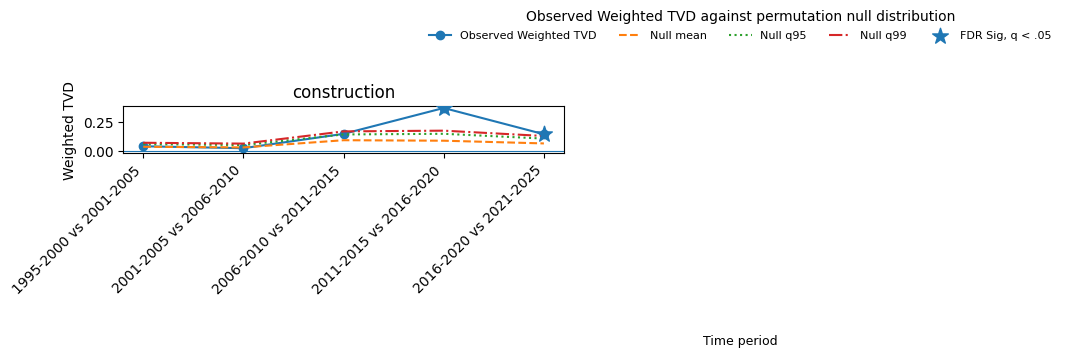

In [28]:
plot_permutation_test_consecutive_dist(perm_result_df)

In [29]:
perm_fdr_summary, corrected_construction_period_df = summarize_fdr_correction(perm_result_df)

perm_fdr_summary
perm_fdr_summary.to_csv(rf"{output_SCD}/construction_perm_fdr_summary.csv", index=False)
# corrected_construction_period_df

In [30]:
perm_fdr_summary

,slot,total_period_tests,valid_period_tests,invalid_period_tests,raw_p_significant,fdr_significant,corrected_by_fdr,raw_significant_percent,fdr_significant_percent,fdr_corrected_percent_of_raw_sig
0,construction,5,5,0,3,2,1,60.0,40.0,33.333333


## Compute period x period distance matrix

In [31]:
period_period_dist_df = compute_period_period_dist(
    sfiller_df=construction_df,
    period_col="subfolder",
    # slot_col='', # Required when the data contains multiple slot/feature types, otherwise set to None.
    min_freq=1,
    measure="tvd",
    mode="data_only",
    weighting=False,
    k=1,
)

fig = plot_period_period_dist(period_period_dist_df)
fig.show()

Computing period-period distribution distance with measure: tvd


## Plot distance time-series

In [32]:
plot_all_dists_by_period(perm_result_df, layout="combined", col_to_plot="observed_statistic")